<a href="https://colab.research.google.com/github/clarachence/prova_11_clara_chence/blob/main/prova_11_clara_chence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 11: NVDA (Nvidia) | Gap de Fuga

**Alvo ($Y$):** 1 se a abertura de hoje superar a máxima (high) de ontem; 0 caso contrário.

**Desafio:** Analisar o comportamento do classificador frente a movimentos exponenciais.

**Aluna:** Clara Chence

# 1. CONFIGURAÇÃO E EXTRAÇÃO


In [59]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [61]:
API_KEY = 'VJY5CWLZK2SN5J53'
simbolo = 'NVDA'
url = (
    f'https://www.alphavantage.co/query'
    f'?function=TIME_SERIES_DAILY'
    f'&symbol={simbolo}'
    f'&outputsize=compact'
    f'&apikey={API_KEY}'
)

dados = requests.get(url).json()
serie = dados.get('Time Series (Daily)', {})
df = pd.DataFrame.from_dict(serie, orient='index')
df.index = pd.to_datetime(df.index)
df = df.sort_index().astype(float)
df.columns = ['abertura', 'maxima', 'minima', 'fechamento', 'volume']

print(f"Registros: {len(df)} | Período: {df.index.min().date()} até {df.index.max().date()}")
df.head()

Registros: 100 | Período: 2025-12-11 até 2026-05-06


,abertura,maxima,minima,fechamento,volume
2025-12-11,180.275,181.320,176.62,180.93,182136641.0
2025-12-12,181.110,182.820,174.62,175.02,204274918.0
2025-12-15,177.936,178.415,175.03,176.29,164775636.0
2025-12-16,176.260,178.490,174.90,177.72,148588098.0
2025-12-17,176.100,176.130,170.31,170.94,222775464.0


# 2. TRATAMENTO E NORMALIZAÇÃO

### Verificar nulos

In [62]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
df = df.dropna()
print(f"\nRegistros após limpeza: {len(df)}")

Valores nulos por coluna:
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
dtype: int64

Registros após limpeza: 100


### Verificar duplicatas

In [63]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


### Estatísticas descritivas


In [64]:
display(df.describe())

,abertura,maxima,minima,fechamento,volume
count,100.000000,100.000000,100.000000,100.000000,1.000000e+02
mean,186.439360,189.014314,183.792628,186.419500,1.700845e+08
std,9.296378,9.509256,9.144694,9.664834,4.484558e+07
min,166.970000,169.450000,164.270000,165.170000,6.552854e+07
25%,179.745000,182.804025,176.560000,180.317500,1.397144e+08
50%,185.495000,188.592500,183.820000,185.510000,1.669630e+08
75%,191.287500,193.512500,187.550000,190.042500,1.880661e+08
max,212.700000,216.825000,208.200000,216.610000,3.608079e+08


### Detectar outliers via IQR

In [65]:
print("Outliers detectados por coluna (método IQR):")
for col in ['abertura', 'maxima', 'minima', 'fechamento', 'volume']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n   = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])
    print(f"  {col}: {n} outliers")

Outliers detectados por coluna (método IQR):
  abertura: 4 outliers
  maxima: 5 outliers
  minima: 3 outliers
  fechamento: 6 outliers
  volume: 4 outliers


# 3. VISUALIZAÇÃO

## Gráfico de Fechamento


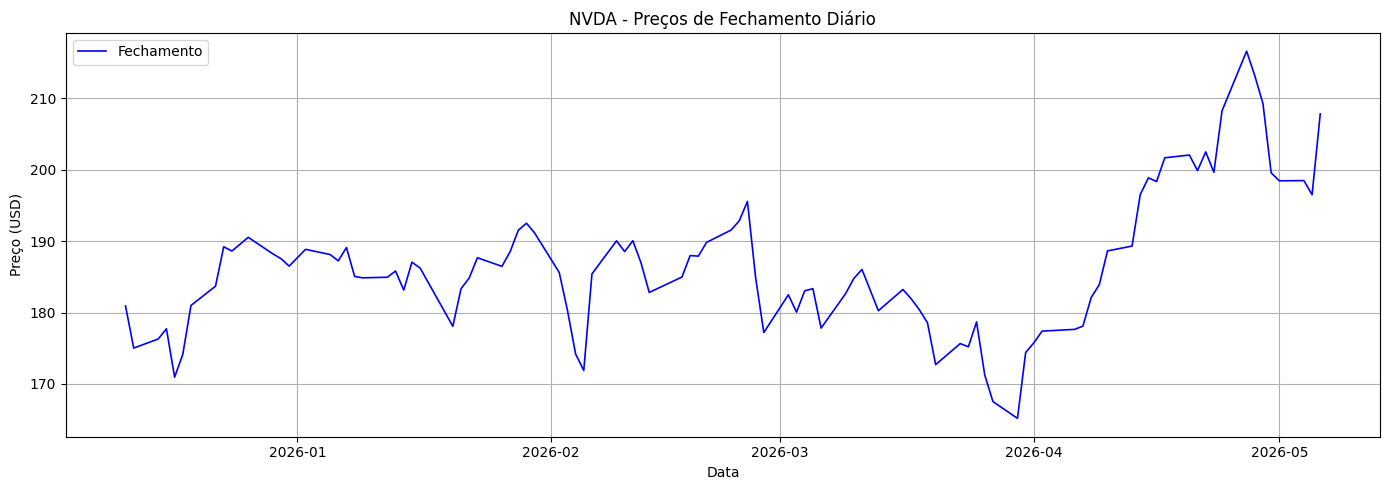

In [66]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['fechamento'], color='blue', linewidth=1.2, label='Fechamento')
plt.title('NVDA - Preços de Fechamento Diário')
plt.xlabel('Data')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Gráfico de Volume

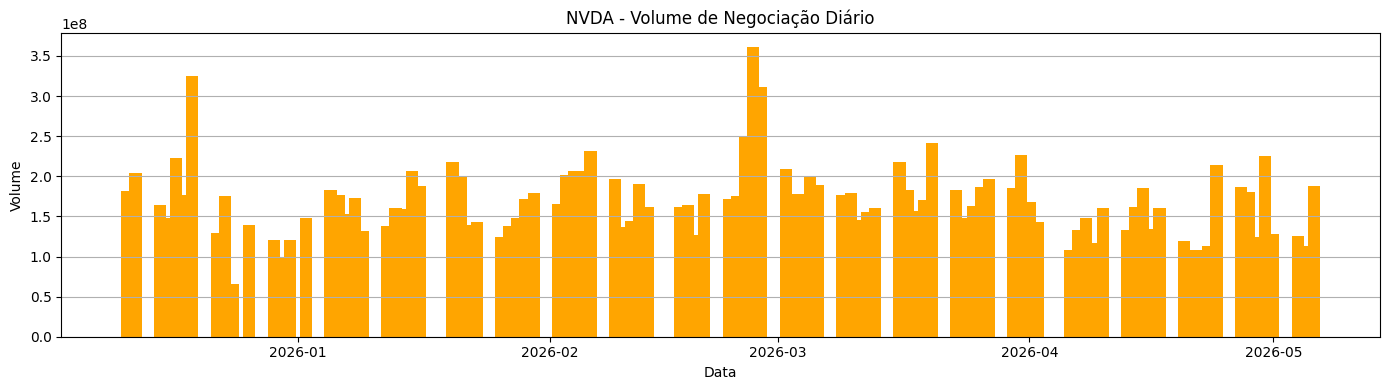

In [67]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['volume'], color='orange', width=1.5)
plt.title('NVDA - Volume de Negociação Diário')
plt.xlabel('Data')
plt.ylabel('Volume')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Correlação entre váriaveis (HeatMap)


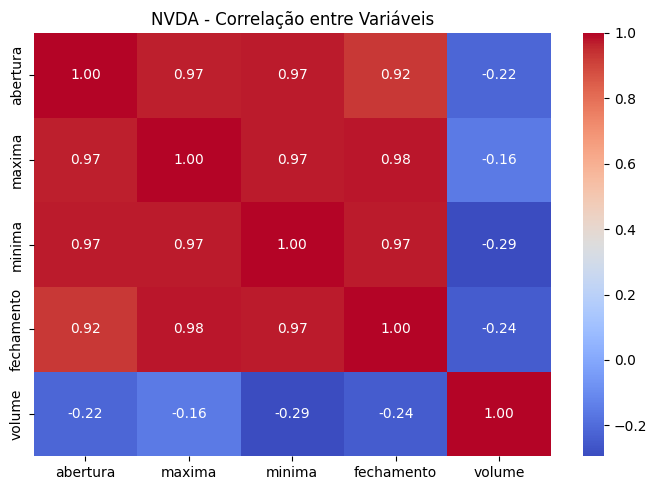

In [68]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[['abertura','maxima','minima','fechamento','volume']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('NVDA - Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# 4. LABORIZAÇÃO

## Target: 1 se a abertura de hoje > máxima de ontem, senão 0

In [69]:
df['abertura_ontem']   = df['abertura'].shift(1)
df['maxima_ontem']     = df['maxima'].shift(1)
df['minima_ontem']     = df['minima'].shift(1)
df['fechamento_ontem'] = df['fechamento'].shift(1)
df['volume_ontem']     = df['volume'].shift(1)
df['variacao_ontem']   = (df['fechamento'] - df['abertura']).shift(1)

In [70]:
df['alvo'] = np.where(df['abertura'] > df['maxima'].shift(1), 1, 0)
df = df.dropna()

In [71]:
print("Distribuição do alvo:")
print(df['alvo'].value_counts())
print(f"\nProporção de Gaps de Fuga (alvo=1): {df['alvo'].mean()*100:.1f}%")
print(f"Total de registros: {len(df)}")

Distribuição do alvo:
alvo
0    82
1    17
Name: count, dtype: int64

Proporção de Gaps de Fuga (alvo=1): 17.2%
Total de registros: 99


### Gráfico de distribuição do alvo

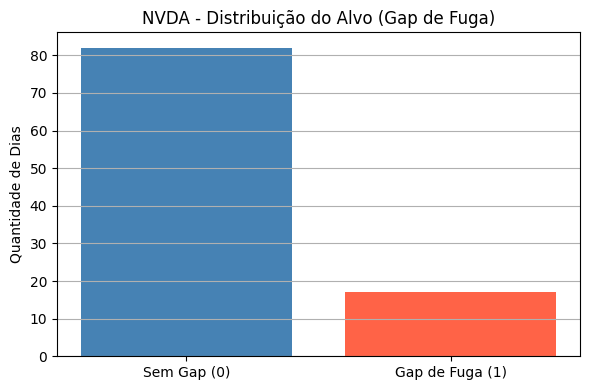

In [72]:
plt.figure(figsize=(6, 4))
contagem = df['alvo'].value_counts()
plt.bar(['Sem Gap (0)', 'Gap de Fuga (1)'], contagem.values,
        color=['steelblue', 'tomato'])
plt.title('NVDA - Distribuição do Alvo (Gap de Fuga)')
plt.ylabel('Quantidade de Dias')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [73]:
X = df[['abertura_ontem', 'maxima_ontem', 'minima_ontem',
        'fechamento_ontem', 'volume_ontem', 'variacao_ontem']]
y = df['alvo']

In [74]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [75]:
scaler   = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste  = scaler.transform(X_teste)

In [76]:
print(f"X_treino: {X_treino.shape} | X_teste: {X_teste.shape}")

X_treino: (69, 6) | X_teste: (30, 6)


# 5. MODELAGEM (NAIVE BAYES)

In [77]:
modelo = GaussianNB(priors=[0.7, 0.3])
modelo.fit(X_treino, y_treino)

GaussianNB(priors=[0.7, 0.3])

In [78]:
y_pred = modelo.predict(X_teste)

print(f"Acurácia: {accuracy_score(y_teste, y_pred) * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(
    y_teste, y_pred,
    target_names=['Sem Gap (0)', 'Gap de Fuga (1)']
))

Acurácia: 70.00%

Relatório de Classificação:
                 precision    recall  f1-score   support

    Sem Gap (0)       0.83      0.79      0.81        24
Gap de Fuga (1)       0.29      0.33      0.31         6

       accuracy                           0.70        30
      macro avg       0.56      0.56      0.56        30
   weighted avg       0.72      0.70      0.71        30



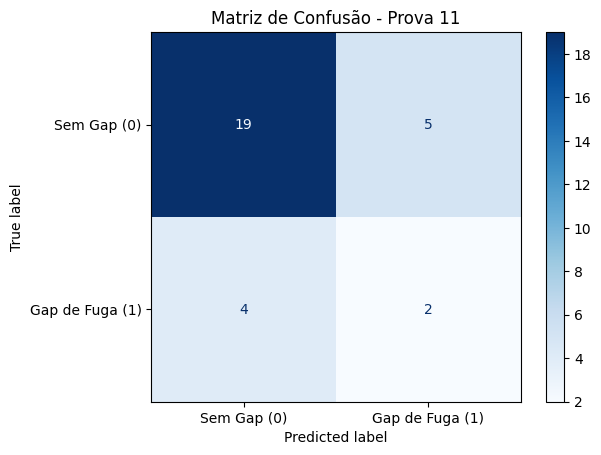

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_teste, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Gap (0)', 'Gap de Fuga (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Prova 11")
plt.show()

# Análise do Desafio

**Prova 11 — NVDA (Nvidia) | Gap de Fuga**

---

## Sobre a Fonte de Dados

Os dados foram extraídos via API Alpha Vantage com o endpoint `TIME_SERIES_DAILY`
e `outputsize=compact`, retornando os últimos 100 pregões da NVDA.
A chave gratuita limita o histórico a 100 registros, o que impacta diretamente
o aprendizado do modelo sobre a classe minoritária (Gap de Fuga).
---

## Sobre o Modelo e Resultados

O modelo GaussianNB apresentou **acurácia de 70.00%**, com os seguintes
f1-scores:

- **Sem Gap (0): 0.81**
- **Gap de Fuga (1): 0.31**

O ajuste de `priors=[0.6SSS, 0.4]` foi necessário para que o modelo considerasse
a classe minoritária, evidenciando a limitação do GaussianNB padrão em
dados desbalanceados.

---
